# 2 · Generative modelling with QBMs

We train a QBM to reproduce a classical probability distribution — the canonical
**bars-and-stripes** dataset — and compare a fully-visible QBM with one that has
hidden units.

## Objectives and gradients

For a fully-visible QBM and a fixed target $\sigma$, the **relative-entropy**
objective $D(\sigma\|\rho(\theta))$ has the classic positive/negative-phase gradient

$$\partial_j D(\sigma\|\rho) = \langle G_j\rangle_\sigma - \langle G_j\rangle_{\rho(\theta)} ,$$

(data expectation minus model expectation) — exact even for non-commuting
generators, and cheap. This is what `qbm.learn` uses.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import qbm

q = qbm.datasets.bars_and_stripes(grid=2)   # distribution over 2^4 = 16 outcomes
print("number of valid patterns:", int((q > 0).sum()))

number of valid patterns: 6


### Learn it in a few lines

`qbm.learn` picks a fully-visible QBM with all-to-all couplings, the
relative-entropy objective, Adam, and the dense backend, with a small random
init to avoid symmetry saddles.

In [2]:
model = qbm.learn(q, steps=600, lr=0.1)
print("final KL(data || model) =", round(model.kl(q), 5))

final KL(data || model) = 0.00069


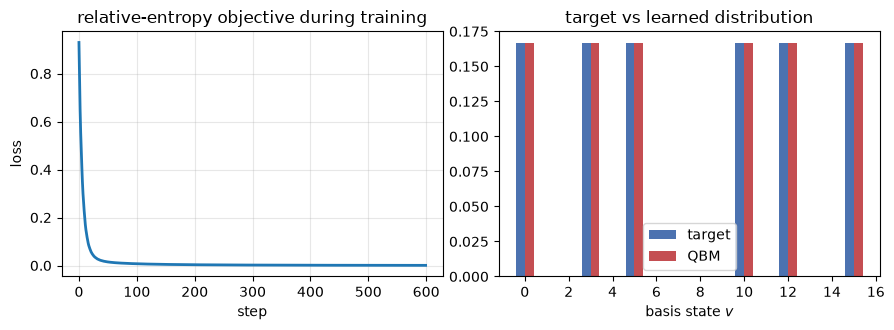

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.4))
axes[0].plot(model.history.loss, lw=2)
axes[0].set_title("relative-entropy objective during training")
axes[0].set_xlabel("step"); axes[0].set_ylabel("loss"); axes[0].grid(alpha=0.3)

x = np.arange(len(q))
w = 0.4
axes[1].bar(x - w/2, q, width=w, label="target", color="#4C72B0")
axes[1].bar(x + w/2, model.probabilities(), width=w, label="QBM", color="#C44E52")
axes[1].set_title("target vs learned distribution")
axes[1].set_xlabel("basis state $v$"); axes[1].legend()
plt.tight_layout(); plt.show()

### Visualise samples as images

Bars-and-stripes patterns live on a 2×2 grid; we draw samples from the trained
QBM and render them.

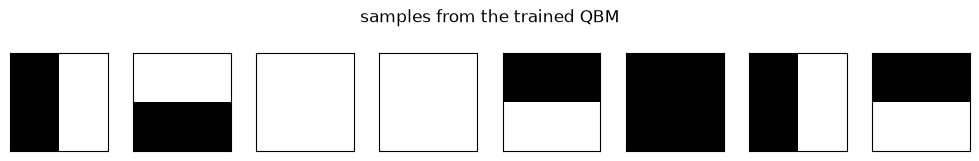

In [4]:
samples = model.sample(8, rng=np.random.default_rng(0))
fig, axes = plt.subplots(1, 8, figsize=(10, 1.6))
for ax, s in zip(axes, samples):
    bits = [(s >> (3 - k)) & 1 for k in range(4)]   # qubit 0 is MSB
    ax.imshow(np.array(bits).reshape(2, 2), cmap="gray_r", vmin=0, vmax=1)
    ax.set_xticks([]); ax.set_yticks([])
fig.suptitle("samples from the trained QBM")
plt.tight_layout(); plt.show()

### Hidden units

A QBM can also have **hidden units** that are traced out; the model distribution
is the visible marginal $p(v) = \mathrm{Tr}_h\,\rho_{vh}$. We train it with the true
measured-distribution likelihood `MarginalNLL`. Hidden units need a random init
(the all-zero point is a symmetry saddle).

hidden-unit QBM final KL = 0.00054


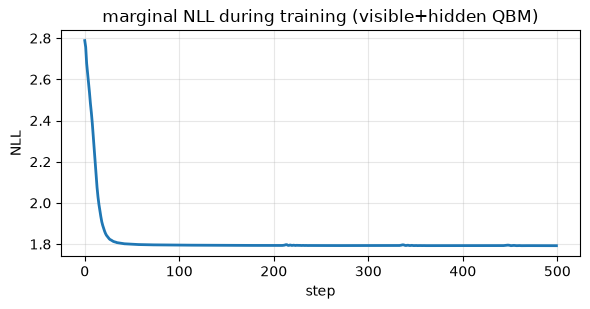

In [5]:
vh = qbm.VisibleHiddenQBM(n_visible=4, n_hidden=3)
vh.theta = np.random.default_rng(0).normal(scale=0.1, size=vh.n_params)
hist = qbm.fit(vh, qbm.losses.MarginalNLL(q, n_visible=4),
               qbm.optim.Adam(lr=0.1), steps=500)
print("hidden-unit QBM final KL =", round(vh.kl(q), 5))

plt.figure(figsize=(6, 3.2))
plt.plot(hist.loss, lw=2)
plt.title("marginal NLL during training (visible+hidden QBM)")
plt.xlabel("step"); plt.ylabel("NLL"); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

### Recap

- `qbm.learn` makes generative modelling a one-liner.
- The relative-entropy gradient is the data-minus-model term expectation.
- Hidden-unit QBMs use the exact marginal-likelihood gradient and need random init.